# HumanLens AI — Multilingual Dataset Analysis

## Objective

HumanLens is intended to operate on multilingual user communication.

The initial target includes:

- English
- Hindi
- Hinglish / Hindi-English code-mixed text
- Other Indian languages where reliable data is available
- Additional world languages supported by suitable datasets

The purpose of this notebook is to identify, inspect and compare
multilingual toxicity datasets before preprocessing and model training.

## Research Principle

English, Hindi and Hinglish should not be assumed to behave identically.

Language-specific performance must therefore be measured separately.

The system should report lower confidence when language coverage or
training data is insufficient rather than claiming universal language
understanding.

## Primary Multilingual Resource

The TextDetox Multilingual Toxicity Dataset will be investigated as
the main multilingual toxicity resource.

It provides binary toxic/non-toxic data across multiple languages,
including Hindi and Hinglish.

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np

print("Libraries ready.")

Libraries ready.


In [2]:
multilingual_dataset = load_dataset(
    "textdetox/multilingual_toxicity_dataset"
)

print(multilingual_dataset)

DatasetDict({
    en: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    ru: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    uk: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    de: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    es: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    am: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    zh: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    ar: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    hi: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    it: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    fr: Dataset({
        features: ['text', 'toxic'],
        num_rows: 5000
    })
    he: Dataset({
        features: ['text', 'toxic

In [3]:
print("Available language splits:")
print("-" * 50)

for language in multilingual_dataset.keys():
    print(f"{language:>5} : {len(multilingual_dataset[language])} rows")

print("\nFeatures by language:")
print("-" * 50)

for language in multilingual_dataset.keys():
    print(f"\nLanguage: {language}")
    print(multilingual_dataset[language].features)

Available language splits:
--------------------------------------------------
   en : 5000 rows
   ru : 5000 rows
   uk : 5000 rows
   de : 5000 rows
   es : 5000 rows
   am : 5000 rows
   zh : 5000 rows
   ar : 5000 rows
   hi : 5000 rows
   it : 5000 rows
   fr : 5000 rows
   he : 2011 rows
  hin : 4363 rows
   tt : 5000 rows
   ja : 5000 rows

Features by language:
--------------------------------------------------

Language: en
{'text': Value('string'), 'toxic': Value('int64')}

Language: ru
{'text': Value('string'), 'toxic': Value('int64')}

Language: uk
{'text': Value('string'), 'toxic': Value('int64')}

Language: de
{'text': Value('string'), 'toxic': Value('int64')}

Language: es
{'text': Value('string'), 'toxic': Value('int64')}

Language: am
{'text': Value('string'), 'toxic': Value('int64')}

Language: zh
{'text': Value('string'), 'toxic': Value('int64')}

Language: ar
{'text': Value('string'), 'toxic': Value('int64')}

Language: hi
{'text': Value('string'), 'toxic': Value('in

In [4]:
print("HumanLens Priority Languages")
print("=" * 50)

priority_languages = {
    "en": "English",
    "hi": "Hindi",
    "hin": "Hinglish"
}

for code, name in priority_languages.items():
    if code in multilingual_dataset:
        data = multilingual_dataset[code]

        print(f"\n{name} ({code})")
        print(f"Number of samples: {len(data)}")
        print(f"Features: {data.features}")
        
        print("\nSample:")
        print(data[0])
    else:
        print(f"\n{name} ({code}) is not available.")

HumanLens Priority Languages

English (en)
Number of samples: 5000
Features: {'text': Value('string'), 'toxic': Value('int64')}

Sample:
{'text': 'The trans women reading this tweet right now is beautiful', 'toxic': 0}

Hindi (hi)
Number of samples: 5000
Features: {'text': Value('string'), 'toxic': Value('int64')}

Sample:
{'text': 'मेरे देश के हिन्दु बहुत निराले है। कुछ तो पक्के राम भक्त है और कुछ बाबर के साले है 🙏 जय श्री राम 🙏', 'toxic': 1}

Hinglish (hin)
Number of samples: 4363
Features: {'text': Value('string'), 'toxic': Value('int64')}

Sample:
{'text': 'Beta to tu apne baap ka hai ...permission to tu maang he liya ab mukr mat smjaaaa ....yehi adat tumlogo ki dagabaazi wali jayegi nahi ....', 'toxic': 0}


In [5]:
import pandas as pd

language_names = {
    "en": "English",
    "ru": "Russian",
    "uk": "Ukrainian",
    "es": "Spanish",
    "de": "German",
    "am": "Amharic",
    "ar": "Arabic",
    "hi": "Hindi",
    "hin": "Hinglish",
    "it": "Italian",
    "fr": "French",
    "he": "Hebrew",
    "ja": "Japanese",
    "tt": "Tatar",
    "zh": "Chinese"
}

frames = []

for code in multilingual_dataset.keys():
    df = multilingual_dataset[code].to_pandas()
    df["language_code"] = code
    df["language"] = language_names.get(code, code)
    frames.append(df)

multilingual_df = pd.concat(frames, ignore_index=True)

print("Unified multilingual dataset created.")
print(f"Total samples: {len(multilingual_df):,}")

multilingual_df.head()

Unified multilingual dataset created.
Total samples: 71,374


,text,toxic,language_code,language
0,The trans women reading this tweet right now i...,0,en,English
1,9) uhhhh i like being lgbt a lot. i feel proud...,0,en,English
2,Hero Rohit Sharma love From Pakistan,0,en,English
3,As a slightly feminine top I appreciate all ma...,0,en,English
4,Delon Love Turkey and brave Turks from Indian ...,0,en,English


In [6]:
print("Samples by language")
print("=" * 50)

language_counts = multilingual_df["language"].value_counts()

print(language_counts)

Samples by language
language
English      5000
Russian      5000
Ukrainian    5000
German       5000
Spanish      5000
Amharic      5000
Chinese      5000
Arabic       5000
Hindi        5000
Italian      5000
French       5000
Tatar        5000
Japanese     5000
Hinglish     4363
Hebrew       2011
Name: count, dtype: int64


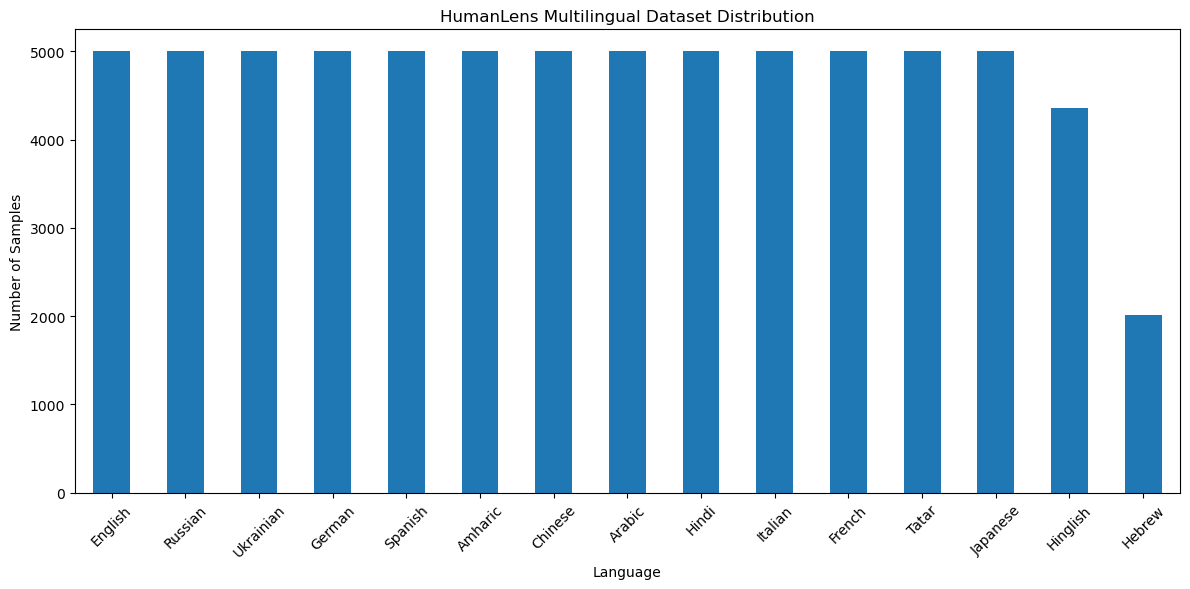

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

language_counts.plot(kind="bar")

plt.title("HumanLens Multilingual Dataset Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [8]:
print("Missing values")
print("=" * 50)

print(multilingual_df.isnull().sum())

Missing values
text             0
toxic            0
language_code    0
language         0
dtype: int64


In [9]:
print("Duplicate texts")
print("=" * 50)

duplicate_count = multilingual_df["text"].duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate texts
Duplicate rows: 1,088


In [10]:
multilingual_df["text_length"] = (
    multilingual_df["text"]
    .astype(str)
    .str.len()
)

print("Text length statistics")
print("=" * 50)

print(multilingual_df["text_length"].describe())

Text length statistics
count    71374.000000
mean        98.055258
std         83.771476
min          1.000000
25%         44.000000
50%         77.000000
75%        121.000000
max       3691.000000
Name: text_length, dtype: float64


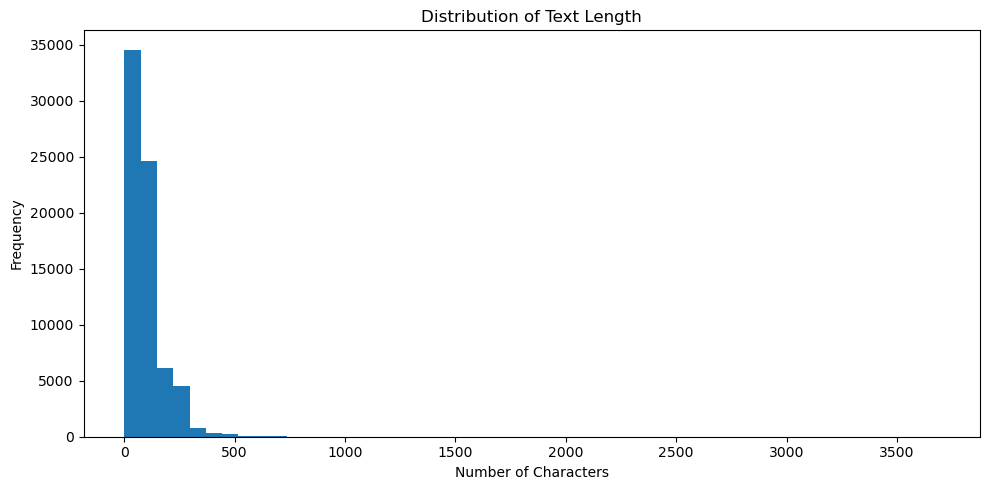

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    multilingual_df["text_length"],
    bins=50
)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
import re

def clean_text(text):
    text = str(text)

    # Remove unnecessary leading/trailing spaces
    text = text.strip()

    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text)

    return text


multilingual_df["clean_text"] = (
    multilingual_df["text"]
    .apply(clean_text)
)

print("Text cleaning completed.")

multilingual_df[
    ["text", "clean_text", "language"]
].head(10)

Text cleaning completed.


,text,clean_text,language
0,The trans women reading this tweet right now i...,The trans women reading this tweet right now i...,English
1,9) uhhhh i like being lgbt a lot. i feel proud...,9) uhhhh i like being lgbt a lot. i feel proud...,English
2,Hero Rohit Sharma love From Pakistan,Hero Rohit Sharma love From Pakistan,English
3,As a slightly feminine top I appreciate all ma...,As a slightly feminine top I appreciate all ma...,English
4,Delon Love Turkey and brave Turks from Indian ...,Delon Love Turkey and brave Turks from Indian ...,English
5,Because it's the Word of God maybe? Just spitb...,Because it's the Word of God maybe? Just spitb...,English
6,God Bless From a Trinidadian Muslim!,God Bless From a Trinidadian Muslim!,English
7,Majority of girls talking to me after they fin...,Majority of girls talking to me after they fin...,English
8,"Nice! As a bi couple, we thoroughly enjoy bi d...","Nice! As a bi couple, we thoroughly enjoy bi d...",English
9,Dark skinned men wearing pink shirts always ma...,Dark skinned men wearing pink shirts always ma...,English


In [12]:
print("Hindi examples")
print("=" * 50)

print(
    multilingual_df[
        multilingual_df["language_code"] == "hi"
    ][["text", "clean_text", "toxic"]]
    .head(10)
)

Hindi examples
                                                    text  \
40000  मेरे देश के हिन्दु बहुत निराले है। कुछ तो पक्क...   
40001  साले जेएनयू छाप कमिने लोग हिन्दुओं को यह कहते ...   
40002  RT मोदीजी और जब सारा देश सेना के साथ खडी है, प...   
40003  RT 48000 घरों को तोड़ने का आदेश आया है, किसी क...   
40004  आजम खान की बेटी पर ससूर ने किया रेप। अब quatat...   
40005  दिल्ली में हिंदुओं और सिक्खों की सामूहिक हत्या...   
40006  कुत्ते में भी एकता होती है विचारों में विरोध ह...   
40007  हा बे कटे लैंड की पैदाइस हलाला की ओलाद तुम्हे ...   
40008  ट्विटर पे बहुत से चूतिये मिलेंगे, जो साले हिंद...   
40009  योगी आदित्यनाथ जी के अथक परिश्रम का ही प्रतिफल...   

                                              clean_text  toxic  
40000  मेरे देश के हिन्दु बहुत निराले है। कुछ तो पक्क...      1  
40001  साले जेएनयू छाप कमिने लोग हिन्दुओं को यह कहते ...      1  
40002  RT मोदीजी और जब सारा देश सेना के साथ खडी है, प...      1  
40003  RT 48000 घरों को तोड़ने का आदेश आया है, किसी क...    

In [13]:
print("\nHinglish examples")
print("=" * 50)

print(
    multilingual_df[
        multilingual_df["language_code"] == "hin"
    ][["text", "clean_text", "toxic"]]
    .head(10)
)


Hinglish examples
                                                    text  \
57011  Beta to tu apne baap ka hai ...permission to t...   
57012  Garibo Kay pas 1000 Kay note bhe nahi hotay vo...   
57013  70 की उम्र के बाद नेताओं को सक्रिय राजनीति से ...   
57014  Retweeted NDTV Videos (@ndtvvideos):  जम्मू-कश...   
57015                          Ms. Chalbaaz. Part 3 of 3   
57016     Kyu ki bevkuf bana kae vote nahi lete yogi ji.   
57017  Desha no 1 chenel bata payege DCHL share kab 7...   
57018  Sambit patra pawan kheda ko bhagao debate se o...   
57019  Kya madam ? Aap ke pita ke saman hain wo vidha...   
57020   price bta do sidha sidha ,aur khtm kro ye show 😂   

                                              clean_text  toxic  
57011  Beta to tu apne baap ka hai ...permission to t...      0  
57012  Garibo Kay pas 1000 Kay note bhe nahi hotay vo...      0  
57013  70 की उम्र के बाद नेताओं को सक्रिय राजनीति से ...      0  
57014  Retweeted NDTV Videos (@ndtvvideos): जम्मू-कश्...

In [14]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "multilingual_toxicity_processed.csv"

multilingual_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset saved successfully.")
print(output_path)

Dataset saved successfully.
..\data\processed\multilingual_toxicity_processed.csv
